In [1]:
import os
%cd /kaggle/working/
if not os.path.exists('yolov12'):
    !git clone https://github.com/sunsmarterjie/yolov12
%cd yolov12
!pip install -r requirements.txt
!pip install -e .
!pip install roboflow

/kaggle/working
Cloning into 'yolov12'...
remote: Enumerating objects: 1169, done.
remote: Total 1169 (delta 0), reused 0 (delta 0), pack-reused 1169 (from 1)
Receiving objects: 100% (1169/1169), 1.95 MiB | 11.87 MiB/s, done.
Resolving deltas: 100% (531/531), done.
/kaggle/working/yolov12
ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Obtaining file:///kaggle/working/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20193 sha256=0448d7e2a93395facf9519c68b68f0c366716f6b37c7ef25d4704cca25295ab4
  Stored in directory: /tmp/pip-ephem-wheel-cache-f3l_3kzx/wheels/e1/69/6a/b9decd48b276a3db8e45bdfecfc351

In [ ]:
from roboflow import Roboflow
import shutil

# Tạo thư mục đích
MERGED_DIR = "/kaggle/working/merged_text_data"
if os.path.exists(MERGED_DIR):
    shutil.rmtree(MERGED_DIR) # Xóa sạch thư mục cũ để làm mới hoàn toàn
os.makedirs(f"{MERGED_DIR}/train/images", exist_ok=True)
os.makedirs(f"{MERGED_DIR}/train/labels", exist_ok=True)

rf = Roboflow(api_key="ASFxhxDHyvirE7sj4Y4B")

# Danh sách bộ dataset
datasets = [
    ("micasheets", "convert-to-yolov8", 2),
    ("kmd1", "-detect2.29", 1),
    ("taa-ewhrv", "line-detection-vylwz", 1),
    ("indianic", "line-1ugq8", 1),
]

def merge_to_unified_text(loc, prefix):
    # Chỉ lấy tập train để merge cho nhanh
    img_src = os.path.join(loc, "train/images")
    lab_src = os.path.join(loc, "train/labels")
    
    if not os.path.exists(lab_src): return
    
    for lab_file in os.listdir(lab_src):
        # Đồng nhất tất cả các class về 0 (text)
        with open(os.path.join(lab_src, lab_file), 'r') as f:
            lines = ["0 " + " ".join(l.split()[1:]) for l in f.readlines()]
            
        with open(f"{MERGED_DIR}/train/labels/{prefix}_{lab_file}", "w") as f:
            f.write("\n".join(lines))
            
        img_file = lab_file.replace('.txt', '.jpg') # Thử với jpg
        if os.path.exists(os.path.join(img_src, img_file)):
            shutil.copy(os.path.join(img_src, img_file), f"{MERGED_DIR}/train/images/{prefix}_{img_file}")

# Tải và thực hiện merge
for workspace, project, version in datasets:
    ds = rf.workspace(workspace).project(project).version(version).download("yolov12")
    merge_to_unified_text(ds.location, project[:5])

print(f"✅ Đã merge xong! Tổng cộng có {len(os.listdir(f'{MERGED_DIR}/train/images'))} ảnh.")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Convert-to-YOLOv8-2 in yolov12:: 100%|██████████| 435/435 [00:00<00:00, 11505.30it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to 中棒detect2.29-1 in yolov12:: 100%|██████████| 2868/2868 [00:00<00:00, 9174.12it/s]


...


Extracting Dataset Version Zip to Line-Detection-1 in yolov12:: 100%|██████████| 607/607 [00:00<00:00, 8690.02it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to line-1 in yolov12:: 100%|██████████| 101/101 [00:00<00:00, 6595.02it/s]

✅ Đã merge xong! Tổng cộng có 1794 ảnh.


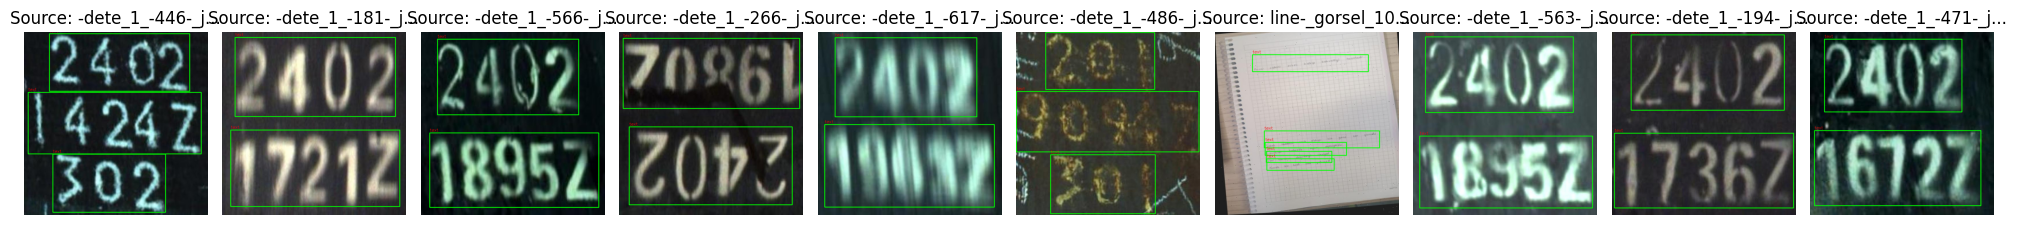

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import random

def visualize_merged_samples(base_path, num_samples=10):
    img_dir = os.path.join(base_path, "train/images")
    lab_dir = os.path.join(base_path, "train/labels")
    
    # Lấy danh sách ảnh
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if not img_files:
        print("❌ Không tìm thấy ảnh trong thư mục merged!")
        return

    # Chọn ngẫu nhiên mẫu
    samples = random.sample(img_files, min(num_samples, len(img_files)))
    
    plt.figure(figsize=(20, 10))
    
    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)
        lab_path = os.path.join(lab_dir, os.path.splitext(img_name)[0] + ".txt")
        
        # Đọc ảnh
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # Đọc và vẽ nhãn
        if os.path.exists(lab_path):
            with open(lab_path, 'r') as f:
                for line in f:
                    # Tọa độ YOLO: class x_center y_center width height
                    parts = line.split()
                    cls = parts[0]
                    # Chuyển từ hệ tọa độ chuẩn hóa sang pixel
                    x_c, y_c, nw, nh = map(float, parts[1:])
                    
                    x1 = int((x_c - nw/2) * w)
                    y1 = int((y_c - nh/2) * h)
                    x2 = int((x_c + nw/2) * w)
                    y2 = int((y_c + nh/2) * h)
                    
                    # Vẽ khung xanh lá (vì là word detection nên vẽ mảnh một chút)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    # Ghi chú Class (Tất cả phải là 0: text)
                    cv2.putText(img, f"text", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Source: {img_name[:15]}...")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Thực hiện visualize từ thư mục đã merge
visualize_merged_samples("/kaggle/working/merged_text_data")

In [ ]:
import os
import gc
import torch
from ultralytics import YOLO

# # 1. Dọn dẹp bộ nhớ GPU
# gc.collect()
# torch.cuda.empty_cache()
# os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

import yaml

config = {
    'path': MERGED_DIR,
    'train': 'train/images',
    'val': 'train/images', # Dùng tạm train làm val để treo máy
    'names': {0: 'text'}
}

with open('/kaggle/working/yolov12/text_det.yaml', 'w') as f:
    yaml.dump(config, f)

# 2. LOAD MODEL CŨ (Đường dẫn đến file .pt)
model_path = '/kaggle/input/datasets/antrn24/okvip2/best3.pt'
if not os.path.exists(model_path):
    print("⚠️ Không tìm thấy file best.pt cũ, hãy kiểm tra lại đường dẫn!")
else:
    model = YOLO(model_path)

# 3. TRAIN TIẾP VỚI CẤU HÌNH LÀM NHIỄU MẠNH
results = model.train(
    data='text_det.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    amp=False,
    name='v12_blur_specialist',
    
    # --- Cấu hình thay thế cho nhiễu và mờ ---
    hsv_h=0.015,  # Thay đổi sắc thái màu
    hsv_s=0.7,    # Thay đổi độ bão hòa
    hsv_v=0.6,    # Tăng mạnh biến động độ sáng (giúp nhận diện tốt hơn trong vùng tối/mờ)
    
    degrees=5.0, # Xoay ảnh
    translate=0.1,
    scale=0.5,
    shear=5.0,
    perspective=0.0001,
    
    # Thay vì blur trực tiếp, ta dùng Mosaic mạnh để ép model học bối cảnh
    mosaic=1.0,   
    mixup=0.1,    
    
    # Hạ thấp Learning Rate để Fine-tune
    lr0=0.001
)

# 4. In kết quả mới
print("✅ Đã hoàn thành khóa huấn luyện bổ túc cho ảnh mờ!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/input/datasets/antrn24/okvip2/best3.pt, data=text_det.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=v12_blur_specialist, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mos

100%|██████████| 755k/755k [00:00<00:00, 16.1MB/s]
E0000 00:00:1776169309.804795      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776169309.917735      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776169310.967418      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776169310.967459      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776169310.967462      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776169310.967464      22 computation_placer.cc:177] comput


                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2, 1, 2]          
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2, 1, 4]        
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  2    677120  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 4]        
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256

train: Scanning /kaggle/working/merged_text_data/train/labels... 1794 images, 29 backgrounds, 0 corrupt: 100%|██████████| 1794/1794 [00:01<00:00, 1374.28it/s]


train: New cache created: /kaggle/working/merged_text_data/train/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 161, len(boxes) = 7620. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      20/20      12.8G     0.8045     0.4982       1.21          9        640: 100%|██████████| 113/113 [01:58<00:00,  1.05s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:35<00:00,  1.60it/s]

                   all       1794       7620      0.936      0.923      0.947      0.732



20 epochs completed in 0.871 hours.
Optimizer stripped from /kaggle/working/yolov12/runs/detect/v12_blur_specialist/weights/last.pt, 18.6MB
Optimizer stripped from /kaggle/working/yolov12/runs/detect/v12_blur_specialist/weights/best.pt, 18.6MB

Validating /kaggle/working/yolov12/runs/detect/v12_blur_specialist/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 376 layers, 9,074,595 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 57/57 [00:36<00:00,  1.57it/s]


                   all       1794       7620      0.921      0.915      0.941      0.734
Speed: 0.2ms preprocess, 15.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/yolov12/runs/detect/v12_blur_specialist
✅ Đã hoàn thành khóa huấn luyện bổ túc cho ảnh mờ!


In [5]:
# Cách truy cập an toàn hơn vào các chỉ số của YOLO
print("--- KẾT QUẢ METRICS CHUẨN XÁC ---")
# Sử dụng trực tiếp đối tượng metrics từ kết quả val của trainer
metrics = results.fitness  # Trả về các chỉ số tổng hợp
print(f"Fitness score (Tổng hợp): {metrics:.4f}")

# Cách in chi tiết từng chỉ số mà không sợ sai Key
m = results.results_dict
print(f"mAP50: {m.get('metrics/m_ap50', m.get('metrics/precision(B)', 'N/A'))}") 

# Cách đơn giản và chắc chắn nhất:
results.print() # Lệnh tự thân của YOLO để in bảng tóm tắt đẹp mắt

--- KẾT QUẢ METRICS CHUẨN XÁC ---
Fitness score (Tổng hợp): 0.7551
mAP50: 0.9212647340106227


AttributeError: 'DetMetrics' object has no attribute 'print'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when t